# Deep Learning-Based Histopathological Image Classification for Lung and Colon Cancer Detection

Objective

The objective of this project is to develop and evaluate deep learning models to accurately classify histopathological images of lung and colon tissues as cancerous or non-cancerous.

## Installing Packages

In [ ]:
pip install imagehash

## Importing Libraries

In [ ]:
import os
import shutil
import random
from tqdm import tqdm
from PIL import Image

import numpy as np
import pandas as pd
import imagehash

import cv2
import matplotlib.image as mpimg


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification

import torchvision.models as models


from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, hamming_loss, precision_recall_curve, roc_curve, auc
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

from openai import OpenAI

## Loading Dataset

In [ ]:
## nested path
DATASET_PATH = "/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set"

# List main folders
print("Main dataset folders:", os.listdir(DATASET_PATH))

# Define paths
lung_path = os.path.join(DATASET_PATH, "lung_image_sets")
colon_path = os.path.join(DATASET_PATH, "colon_image_sets")

print("\nLung set classes:", os.listdir(lung_path))
print("Colon set classes:", os.listdir(colon_path))


## Exploratory Data Analysis

### Class Distribution


In [ ]:
# Defines the classes for lung and colon images to be analyzed
lung_classes = ['lung_n', 'lung_aca', 'lung_scc']
colon_classes = ['colon_n', 'colon_aca']

class_counts = {}

# Counts the number of images for each lung class by reading directory contents
for cls in lung_classes:
    path = os.path.join(DATASET_PATH, "lung_image_sets", cls)
    class_counts[cls] = len(os.listdir(path))

# Counts the number of images for each colon class by reading directory contents
for cls in colon_classes:
    path = os.path.join(DATASET_PATH, "colon_image_sets", cls)
    class_counts[cls] = len(os.listdir(path))

# Creates a bar chart to visualise image distribution across all classes
STANDARD_FIGSIZE = (8,6)
plt.figure(figsize=STANDARD_FIGSIZE)

bars = plt.bar(class_counts.keys(), class_counts.values(), color='teal')

# Enhances chart aesthetics with title, labels, and customized tick sizes
plt.title("Class Distribution in LC25000 Dataset", fontsize=18, fontweight='bold')
plt.xlabel("Classes", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Number of Images", fontsize=14, fontweight='bold', fontstyle='italic')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add annotations on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5,
             str(height), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

The LC25000 dataset demonstrates a perfectly balanced class distribution, with each of the five classes containing 5000 images, summing to 25000 samples. This uniform allocation minimizes class imbalance, supporting unbiased model training and ensuring equal representation for lung and colon conditions across both normal and cancerous categories.

### Sample Images per Class

In [ ]:
# Maps class codes to their full descriptive names for better readability
class_name_map = {
    "lung_n": "Lung Benign Tissue",
    "lung_aca": "Lung Adenocarcinoma",
    "lung_scc": "Lung Squamous Cell Carcinoma",
    "colon_n": "Colon Benign Tissue",
    "colon_aca": "Colon Adenocarcinoma"
}

# Defines number of sample images to display for each class
samples_per_class = 5

# Creates a grid of subplots to display multiple samples per class
fig, axes = plt.subplots(len(class_counts), samples_per_class, figsize=(STANDARD_FIGSIZE[0]*1.25, STANDARD_FIGSIZE[1]*2))

# Iterates through each class and randomly selects sample images for visualization
for row, cls in enumerate(class_counts.keys()):
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)

    img_files = random.sample(os.listdir(folder), samples_per_class)

    for col, img_file in enumerate(img_files):
        img_path = os.path.join(folder, img_file)
        img = mpimg.imread(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')

        # Highlights the class name in the center column for better identification
        if col == samples_per_class // 2:
            axes[row, col].set_title(
                class_name_map.get(cls, cls), fontsize=18, fontweight='bold', fontstyle='italic',color='black', backgroundcolor=(1, 1, 1, 0.6))

# Adds a main title above the entire grid of images
plt.suptitle("Sample Images from Each Class", fontsize=18, fontweight='bold')

# Ensures the layout remains clear and prevents overlapping elements
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Tissue Coverage Percentage

In [ ]:
# Defines a set of teal color shades for consistent visual theme
teal_palette = ['#008080', '#009688', '#20B2AA', '#40E0D0', '#5F9EA0']

# Calculates the percentage of tissue area in an image based on pixel intensity
def tissue_percentage(image):
    gray = np.mean(image, axis=2) if image.ndim == 3 else image
    tissue_mask = gray < 200
    return np.sum(tissue_mask) / tissue_mask.size * 100

# Initializes storage for tissue coverage statistics of each class
tissue_stats = {cls: [] for cls in class_counts.keys()}

# Samples 100 images from each class and computes their tissue coverage
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    sample_files = random.sample(os.listdir(folder), 100)
    for f in tqdm(sample_files, desc=f"Processing {cls}"):
        img = mpimg.imread(os.path.join(folder, f))
        tissue_stats[cls].append(tissue_percentage(img))

# Creates a histogram grid to visualize tissue percentage distribution across classes
num_classes = len(class_counts)
cols = 2
rows = (num_classes + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(9, 8))
axes = axes.flatten()

# Plots histogram for each class with customized titles and labels
for idx, (cls, values) in enumerate(tissue_stats.items()):
    axes[idx].hist(values, bins=30, color=teal_palette[idx % len(teal_palette)], alpha=0.7)
    axes[idx].set_title(class_name_map.get(cls, cls), fontsize=14, fontweight='bold', fontstyle='italic')
    axes[idx].set_xlabel("Tissue %", fontsize=12, fontstyle='italic')
    axes[idx].set_ylabel("Frequency", fontsize=12, fontstyle='italic')
    axes[idx].tick_params(axis='both', labelsize=10)

# Removes empty subplot spaces if total classes do not fill the grid
for j in range(len(tissue_stats), len(axes)):
    fig.delaxes(axes[j])

# Adds a main title and arranges layout to avoid overlap
plt.suptitle("Tissue Coverage Percentage per Class", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


Lung squamous cell carcinoma exhibits the highest tissue coverage concentration with values clustering between 90 and 100 percent, indicating dense tissue regions. Colon benign tissue remains lower, mostly between 20 and 45 percent. Lung adenocarcinoma shows wider variability ranging from 40 to 98 percent, reflecting heterogeneous tissue distribution.

### Average RGB Intensity per Class

In [ ]:
# Initialises storage for mean RGB values of each class
color_means = {cls: [] for cls in class_counts.keys()}

# Samples 100 images per class and computes their mean RGB values
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    sample_files = random.sample(os.listdir(folder), 100)
    for f in sample_files:
        img = mpimg.imread(os.path.join(folder, f))
        color_means[cls].append(np.mean(img, axis=(0, 1)))

# Aggregates the mean RGB values for each class across all sampled images
class_rgb = {cls: np.mean(vals, axis=0) for cls, vals in color_means.items()}

# Creates a grouped bar plot to display average RGB intensities per class
STANDARD_FIGSIZE = (9, 6)
plt.figure(figsize=STANDARD_FIGSIZE)

x = np.arange(len(class_rgb))
r_means = [v[0] for v in class_rgb.values()]
g_means = [v[1] for v in class_rgb.values()]
b_means = [v[2] for v in class_rgb.values()]

bar_width = 0.25

bars_r = plt.bar(x - bar_width, r_means, bar_width, label='Red', color='red', alpha=0.7)
bars_g = plt.bar(x, g_means, bar_width, label='Green', color='green', alpha=0.7)
bars_b = plt.bar(x + bar_width, b_means, bar_width, label='Blue', color='blue', alpha=0.7)

# Adds numerical annotations above each bar for clarity
for bars in [bars_r, bars_g, bars_b]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 2,
                 f'{height:.1f}', ha='center', va='bottom', fontsize=10)

# Enhances plot with title, axis labels, rotated ticks, and a repositioned legend
plt.title("Mean RGB Intensities per Class", fontsize=18, fontweight='bold')
plt.xlabel("Classes", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Intensity (0–255)", fontsize=14, fontweight='bold', fontstyle='italic')

plt.xticks(x, class_rgb.keys(), rotation=30, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=3)
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()


Colon adenocarcinoma shows the highest blue intensity at 233.6, while lung squamous cell carcinoma records the lowest green intensity at 117.2, indicating stronger blue dominance in cancerous tissues. Normal colon tissue has the highest red intensity at 212.8, highlighting noticeable chromatic differences between normal and malignant tissue samples.

### Image Dimension Distribution (Width & Height)

In [ ]:
# Initialises lists to store image dimensions and corresponding class labels
widths, heights, labels = [], [], []

# Samples 100 images per class and extracts their width and height
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    sample_files = random.sample(os.listdir(folder), 100)
    for f in sample_files:
        img = mpimg.imread(os.path.join(folder, f))
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)
        labels.append(cls)

# Creates overlapping histograms to visualize image width and height distribution
plt.figure(figsize=(8, 6))
plt.hist(widths, bins=30, alpha=0.5, label='Width', color='teal')
plt.hist(heights, bins=30, alpha=0.5, label='Height', color='cadetblue')

# Adds title, labels, and legend for better readability
plt.title("Image Size Distribution", fontsize=18, fontweight='bold')
plt.xlabel("Pixels", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Frequency", fontsize=14, fontweight='bold', fontstyle='italic')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


All images maintain a uniform resolution of 768 by 768 pixels, with both width and height exhibiting identical frequency peaks at 500 occurrences. This standardized image size ensures consistent spatial dimensions across the dataset, reducing preprocessing complexity and enabling seamless input compatibility for deep learning models.

### Brightness Distribution of Images

In [ ]:
# Initialises brightness statistics container for each class
brightness_stats = {cls: [] for cls in class_counts.keys()}

# Samples 100 images per class and computes their average brightness
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    sample_files = random.sample(os.listdir(folder), 100)
    for f in tqdm(sample_files, desc=f"Processing {cls}"):
        img = mpimg.imread(os.path.join(folder, f))
        brightness_stats[cls].append(img.mean())

# Creates a grid of histograms to visualize brightness distribution for each class
num_classes = len(class_counts)
cols = 2
rows = (num_classes + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(9, 8))
axes = axes.flatten()

# Plots class-wise brightness histograms with styled titles and labels
for idx, (cls, values) in enumerate(brightness_stats.items()):
    axes[idx].hist(values, bins=30,
                   color=teal_palette[idx % len(teal_palette)],
                   alpha=0.7)
    axes[idx].set_title(cls,
                        fontsize=14, fontweight='bold', fontstyle='italic')
    axes[idx].set_xlabel("Mean Brightness", fontsize=12, fontstyle='italic')
    axes[idx].set_ylabel("Frequency", fontsize=12, fontstyle='italic')
    axes[idx].tick_params(axis='both', labelsize=10)

# Removes any unused subplot placeholders for a cleaner layout
for j in range(len(brightness_stats), len(axes)):
    fig.delaxes(axes[j])

# Adds a main title and adjusts layout to prevent overlapping
plt.suptitle("Brightness Distribution per Class", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


Colon benign tissue exhibits the highest brightness range with values clustering between 205 and 215, while lung squamous cell carcinoma shows the lowest brightness concentration between 160 and 170. This indicates a notable contrast in luminance between colon and lung samples, potentially affecting segmentation and classification performance.

### RGB Channel Correlation Map

In [ ]:
# Collects mean RGB values from 100 randomly selected images per class
all_rgb = []
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    sample_files = random.sample(os.listdir(folder), 100)
    for f in sample_files:
        img = mpimg.imread(os.path.join(folder, f))
        mean_rgb = np.mean(img, axis=(0, 1))
        all_rgb.append(mean_rgb)

# Converts collected values to an array and computes RGB channel correlations
all_rgb = np.array(all_rgb)
corr_matrix = np.corrcoef(all_rgb.T)

# Visualises the correlation between RGB channels using a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu',
            xticklabels=['Red','Green','Blue'],
            yticklabels=['Red','Green','Blue'])

# Adds a title and optimizes layout for better readability
plt.title("RGB Channel Correlation Heatmap", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

Red and green channels show a strong positive correlation of 0.9, indicating similar intensity variations across samples. Blue channel exhibits weak correlation with red at -0.031 and low correlation with green at 0.22, suggesting that blue contributes distinct intensity characteristics compared to the other two channels.

### Class wise Mosaic

In [ ]:
# Defines the number of images in each mosaic and their resize dimensions
mosaic_cols = 5
mosaic_size = (224, 224)

# Iterates through each class to create a horizontal image mosaic
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    sample_files = random.sample(os.listdir(folder), mosaic_cols)
    images = [Image.open(os.path.join(folder, f)).resize(mosaic_size) for f in sample_files]

    # Calculates total width and max height for the mosaic canvas
    widths, heights = zip(*(img.size for img in images))
    mosaic = Image.new('RGB', (sum(widths), max(heights)))

    # Pastes each image side by side to form a combined mosaic
    x_offset = 0
    for img in images:
        mosaic.paste(img, (x_offset, 0))
        x_offset += img.size[0]

    # Displays the generated mosaic for the current class
    plt.figure(figsize=(10, 5))
    plt.imshow(mosaic)
    plt.axis('off')
    plt.title(f"Class Mosaic: {cls}", fontsize=18, fontweight='bold')
    plt.show()

This class mosaic represents colon_n, showing repeating regions of organised glandular architecture typical of normal colon tissue. The tiled layout highlights structural consistency, with uniform epithelial rings, clear luminal spaces, and balanced cellular distribution across patches.

Such mosaics help verify dataset coherence by revealing shared morphological patterns rather than isolated features. The visual continuity supports that samples labelled colon_n exhibit stable histologic structure, reinforcing label reliability and providing intuitive confirmation that the model is learning from consistent, biologically meaningful tissue organisation.

### Edge Density Distribution per class

In [ ]:
# Initialises a container to store edge density statistics for each class
edge_density_stats = {cls: [] for cls in class_counts.keys()}

# Defines a function to calculate edge density using Canny edge detection
def edge_density(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    return np.sum(edges > 0) / edges.size * 100

# Samples 100 images per class and computes their edge density values
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    sample_files = random.sample(os.listdir(folder), 100)
    for f in tqdm(sample_files, desc=f"Processing {cls}"):
        img = cv2.cvtColor(cv2.imread(os.path.join(folder, f)), cv2.COLOR_BGR2RGB)
        edge_density_stats[cls].append(edge_density(img))

# Converts edge density data into a flattened structure for Seaborn plotting
classes = []
values = []
for cls, vals in edge_density_stats.items():
    classes.extend([cls] * len(vals))
    values.extend(vals)

# Creates a boxplot to visualize edge density distribution across classes
STANDARD_FIGSIZE = (9, 6)
plt.figure(figsize=STANDARD_FIGSIZE)
ax = sns.boxplot(x=classes, y=values,
                 palette=['#008080', '#009688', '#20B2AA', '#40E0D0', '#5F9EA0'],
                 width=0.6)

# Adds median annotations for each class to highlight central tendency
medians = []
for i, box in enumerate(ax.artists):
    median = np.median(edge_density_stats[list(class_counts.keys())[i]])
    medians.append(median)
    ax.annotate(f'{median:.1f}%',
                xy=(i, median),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color='black')

# Adds title, axis labels, and formatted ticks for clarity
plt.title("Edge Density Distribution per Class", fontsize=18, fontweight='bold')
plt.xlabel("Classes", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Edge Density (%)", fontsize=14, fontweight='bold', fontstyle='italic')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


Colon adenocarcinoma shows the highest edge density variation, ranging from 0.5 to 18 percent, indicating more complex structural patterns. Normal colon tissue follows with a median around 6 percent. Lung classes exhibit significantly lower densities, mostly between 0 and 3 percent, reflecting smoother texture characteristics.

### Dominant Hue Distribution

In [ ]:
# Initialises storage for dominant hue values of each class
dominant_hue_stats = {cls: [] for cls in class_counts.keys()}

# Defines a function to calculate the median hue of an image
def dominant_hue(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    return np.median(hsv[:, :, 0])  # median hue value

# Samples 100 images per class and computes their dominant hue
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    sample_files = random.sample(os.listdir(folder), 100)
    for f in tqdm(sample_files, desc=f"Processing {cls}"):
        img = cv2.cvtColor(cv2.imread(os.path.join(folder, f)), cv2.COLOR_BGR2RGB)
        dominant_hue_stats[cls].append(dominant_hue(img))

# Converts the collected data
classes = []
hues = []
for cls, vals in dominant_hue_stats.items():
    classes.extend([cls] * len(vals))
    hues.extend(vals)

# Creates a violin plot to visualize dominant hue distribution per class
plt.figure(figsize=(10, 6))
ax = sns.violinplot(x=classes, y=hues,
                    palette=['#008080', '#009688', '#20B2AA', '#40E0D0', '#5F9EA0'],
                    inner='quartile')

# Adds title, axis labels, and formatted tick marks for clarity
plt.title("Dominant Hue Distribution per Class", fontsize=18, fontweight='bold')
plt.xlabel("Classes", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Dominant Hue (0–180)", fontsize=14, fontweight='bold', fontstyle='italic')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


Lung normal tissue shows the widest hue variability ranging from 15 to 170, indicating diverse color tones. Other classes, including lung squamous cell carcinoma and colon adenocarcinoma, cluster tightly between 125 and 140, suggesting more stable color distribution across malignant tissues compared to normal lung samples.

### Saturation vs Brightness Plot

In [ ]:
# Defines unique markers and colors to visually distinguish classes
markers = ['o', 's', 'D', '^', 'v']
colors = ['#008080', '#009688', '#20B2AA', '#40E0D0', '#5F9EA0']

# Initialises storage for saturation and brightness values of each class
saturation_brightness = {cls: [] for cls in class_counts.keys()}

# Extracts mean saturation and brightness from an image in HSV color space
def saturation_brightness_pair(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    sat = np.mean(hsv[:, :, 1])  # saturation
    val = np.mean(hsv[:, :, 2])  # brightness
    return sat, val

# Samples 100 images per class and computes their saturation–brightness pairs
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    sample_files = random.sample(os.listdir(folder), 100)
    for f in tqdm(sample_files, desc=f"Processing {cls}"):
        img = cv2.cvtColor(cv2.imread(os.path.join(folder, f)), cv2.COLOR_BGR2RGB)
        saturation_brightness[cls].append(saturation_brightness_pair(img))

# Creates scatter plots to visualize saturation vs brightness for each class
num_classes = len(class_counts)
cols = 2
rows = (num_classes + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
axes = axes.flatten()

# Plots each class with distinct marker, color, and labeled axes
for idx, (cls, vals) in enumerate(saturation_brightness.items()):
    sat_vals, bright_vals = zip(*vals)
    axes[idx].scatter(sat_vals, bright_vals,
                      alpha=0.6,
                      marker=markers[idx % len(markers)],
                      color=colors[idx % len(colors)],
                      label=cls)
    axes[idx].set_title(cls, fontsize=14, fontweight='bold', fontstyle='italic')
    axes[idx].set_xlabel("Mean Saturation", fontsize=12, fontstyle='italic')
    axes[idx].set_ylabel("Mean Brightness", fontsize=12, fontstyle='italic')
    axes[idx].tick_params(axis='both', labelsize=10)
    axes[idx].grid(alpha=0.3)
    axes[idx].legend(fontsize=10, loc='upper right')

# Removes unused subplot placeholders if classes do not fill the grid
for j in range(len(saturation_brightness), len(axes)):
    fig.delaxes(axes[j])

# Adds a main title and adjusts layout for better spacing
plt.suptitle("Saturation vs Brightness per Class", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

Lung adenocarcinoma and squamous cell carcinoma exhibit higher saturation ranges between 90 and 160 with brightness clustering around 220, suggesting more vivid color intensity in malignant lung tissues. Colon tissues maintain lower saturation between 40 and 80 with brightness exceeding 230, indicating relatively pale and less saturated visual characteristics.

## Preprocessing

### Preview Preprocessing step for verification

In [ ]:
# Select one sample image from each class
sample_paths = []
for cls in class_counts.keys():
    folder = os.path.join(DATASET_PATH,
                          "lung_image_sets" if "lung" in cls else "colon_image_sets",
                          cls)
    # Select the first image from each class
    sample_paths.append(os.path.join(folder, os.listdir(folder)[0]))

# Simple H&E stain normalization function (Min-Max scaling)
def he_stain_normalization(image):

    return cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

# Visualization: Original vs H&E Normalized
fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, len(sample_paths) * 3))

for i, path in enumerate(sample_paths):
    original = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    normalized = he_stain_normalization(original)

    # Original image
    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original", fontsize=14, fontweight='bold')
    axes[i, 0].axis('off')

    # Normalized image
    axes[i, 1].imshow(normalized)
    axes[i, 1].set_title("H&E Normalized", fontsize=14, fontweight='bold')
    axes[i, 1].axis('off')

plt.suptitle("Step 1: H&E Stain Normalization", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


The visual comparison demonstrates that H and E stain normalisation produces more consistent colour balance, improved contrast, and clearer cellular detail across samples, reducing variability while preserving morphology. Originals show uneven hues, whereas normalised images appear harmonised, aiding reliable interpretation, comparative analysis, and downstream model training by standardising visual features without obscuring diagnostically relevant structures, textures, or spatial relationships overall.

In [ ]:
# Function applies a sharpening kernel to enhance image edges
def sharpen_image(image):
    # Defines a sharpening kernel to emphasise details
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(image, -1, kernel)

# Creates a subplot layout to compare original and sharpened images
fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, len(sample_paths) * 3))

# Iterates through each selected image for sharpening demonstration
for i, path in enumerate(sample_paths):
    # Reads and converts the image from BGR to RGB format
    original = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

    # Applies the sharpening function to the image
    sharpened = sharpen_image(original)

    # Displays the original image on the left side of the subplot
    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original", fontsize=14, fontweight='bold')
    axes[i, 0].axis('off')

    # Displays the sharpened image on the right side of the subplot
    axes[i, 1].imshow(sharpened)
    axes[i, 1].set_title("Sharpened", fontsize=14, fontweight='bold')
    axes[i, 1].axis('off')

# Adds a main title to the figure for better clarity
plt.suptitle("Step 2: Image Sharpening", fontsize=18, fontweight='bold')

# Adjusts layout to avoid overlapping of titles and images
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Displays the final visualization
plt.show()


Sharpening enhances edge definition, boosts local contrast, and reveals finer cellular boundaries, making structures appear crisper and more distinguishable. Original images look slightly soft, while sharpened versions present clearer nuclei, membranes, and textures. This improvement supports visual assessment, feature extraction, and model learning by emphasising diagnostically relevant details without introducing major artefacts or distorting underlying morphology across varied tissue samples consistently.

In [ ]:
# Function resizes an image to a specified target size
def resize_image(image, target_size=(224, 224)):
    # Resizes the image using area interpolation for better quality
    return cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

# Creates a subplot layout to compare original and resized images
fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, len(sample_paths) * 3))

# Iterates through each selected image to demonstrate resizing effect
for i, path in enumerate(sample_paths):
    # Reads and converts the image from BGR to RGB format
    original = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

    # Resizes the image to the target dimensions
    resized = resize_image(original)

    # Displays the original image on the left side of the subplot
    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original", fontsize=14, fontweight='bold')
    axes[i, 0].axis('off')

    # Displays the resized image on the right side of the subplot
    axes[i, 1].imshow(resized)
    axes[i, 1].set_title("Resized (224×224)", fontsize=14, fontweight='bold')
    axes[i, 1].axis('off')

# Adds a main title to indicate the current preprocessing step
plt.suptitle("Step 3: Image Resizing", fontsize=18, fontweight='bold')

# Adjusts layout for proper spacing between titles and images
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Displays the side-by-side comparison of original and resized images
plt.show()


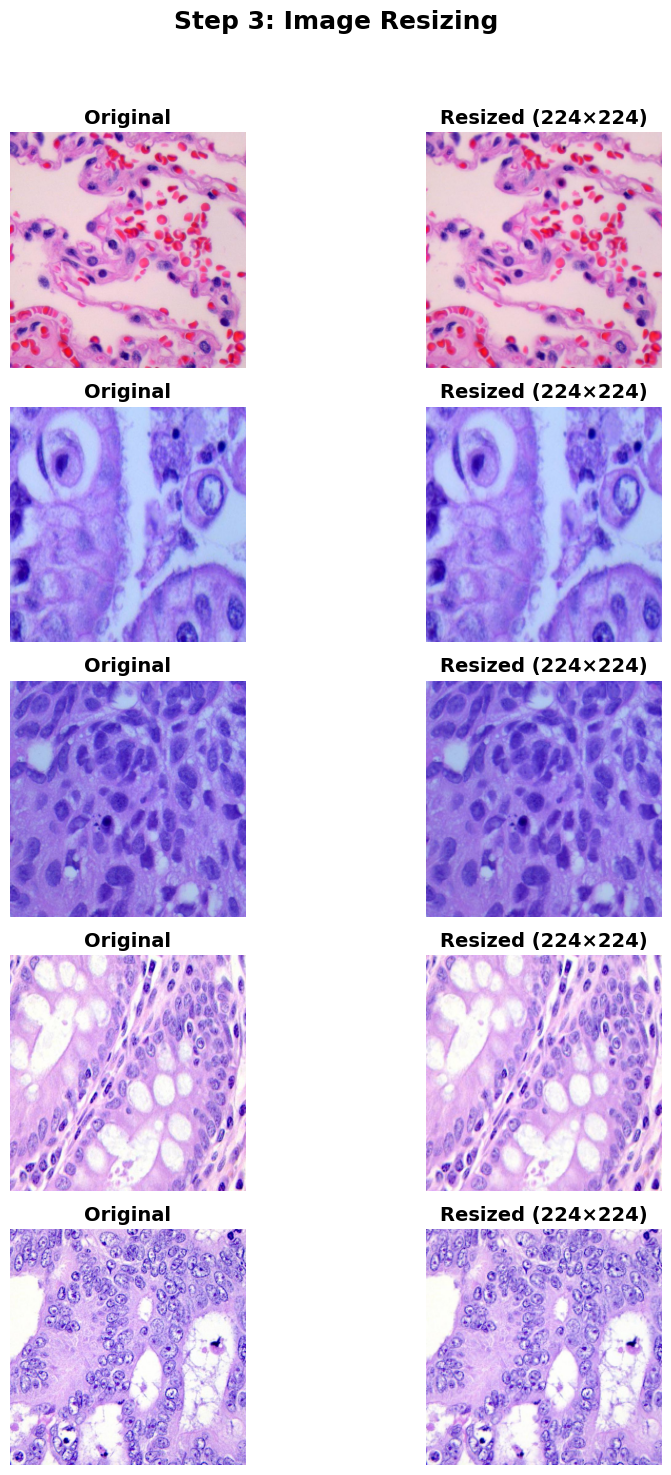

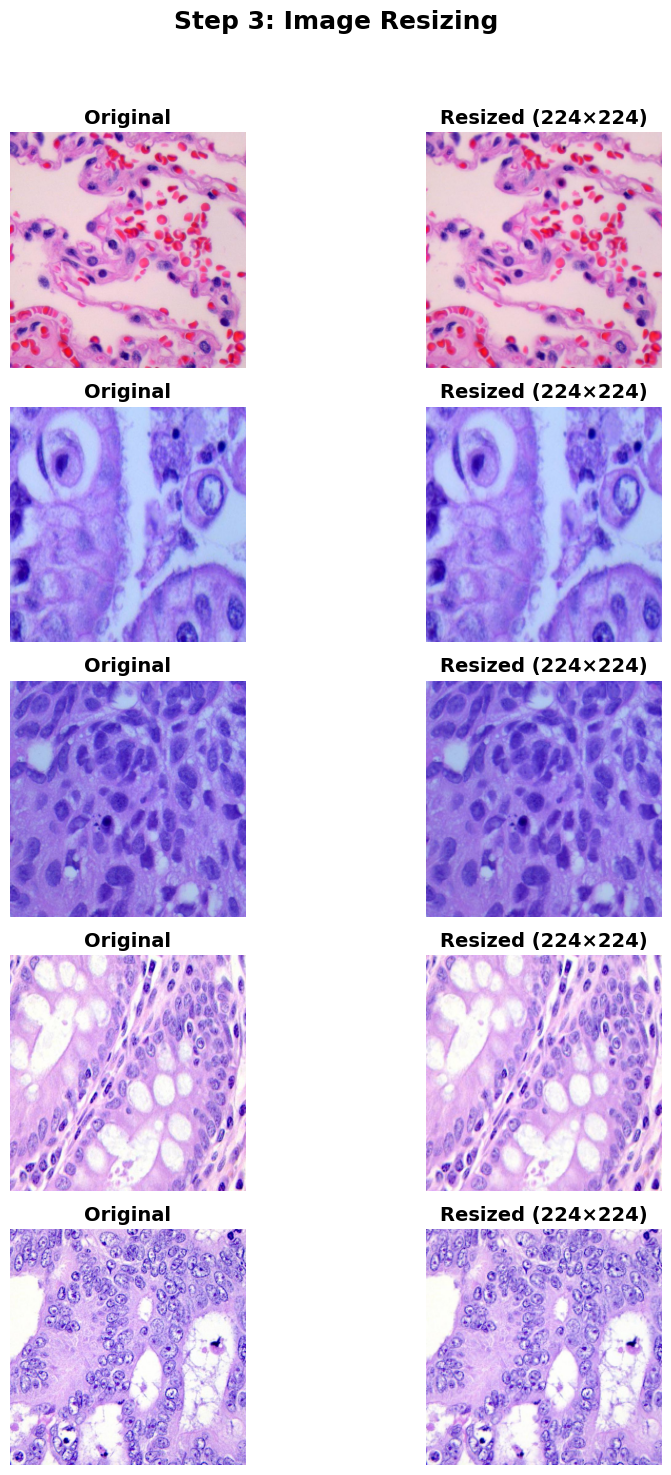

Resizing standardises spatial dimensions to 224 by 224, ensuring uniform input scale while preserving key histological patterns. Original images vary in resolution, but resized versions maintain recognisable nuclei, textures, and tissue organisation. This consistency improves batching, computational efficiency, and model compatibility, enabling stable training and fair comparison without materially degrading diagnostically important visual information across diverse microscopic samples.

In [ ]:
# Converts the image pixel values to a floating-point scale between 0 and 1
def scale_image(image):
    return image.astype(np.float32) / 255.0

# Creates a subplot layout to compare original and scaled images
fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, len(sample_paths) * 3))

# Iterates through each sample image to demonstrate scaling
for i, path in enumerate(sample_paths):
    # Reads the image and converts it from BGR to RGB color space
    original = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

    # Applies per-channel scaling to normalize pixel intensity
    scaled = scale_image(original)

    # Displays the original image on the left side
    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original", fontsize=14, fontweight='bold')
    axes[i, 0].axis('off')

    # Displays the scaled image on the right side
    axes[i, 1].imshow(scaled)
    axes[i, 1].set_title("Scaled (0–1)", fontsize=14, fontweight='bold')
    axes[i, 1].axis('off')

# Adds an overall title to indicate this preprocessing step
plt.suptitle("Step 4: Per-Channel Scaling", fontsize=18, fontweight='bold')

# Adjusts the figure layout for proper spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Renders the comparison between original and scaled images
plt.show()


Per channel scaling maps pixel intensities into the 0-1 range, producing numerically stable inputs while preserving visible histological structure. Originals retain appearance, yet scaled representations standardise dynamic range, improving gradient behaviour, convergence, and cross sample comparability for training pipelines, ensuring consistent optimisation without altering diagnostically meaningful colour relationships or spatial detail, supporting reproducible analysis across varied tissue images and experiments.

### Apply Preprocesssing

In [ ]:
# Paths
DATASET_PATH = "/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set"
OUTPUT_PATH = "/kaggle/working/lung_colon_preprocessed"

H and E stain normalisation standardises colour variation in histopathology images caused by differences in staining protocols, scanners, and lighting. It aligns colour distributions to a reference appearance so tissue structures remain visually comparable across samples.

This consistency improves model training stability and feature learning by reducing colour bias, allowing algorithms to focus on morphology rather than acquisition artefacts. As a result, classification reliability and cross dataset generalisation are strengthened.

In [ ]:
def he_stain_normalisation(image):
    # Normalise pixel intensity values to reduce staining variability
    return cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

Image sharpening is a preprocessing technique that enhances edges and fine structural details by increasing local contrast. In histopathology, it helps emphasise cellular boundaries and tissue textures that may otherwise appear blurred.

By making salient features more distinct, sharpening can support better visual interpretation and improve downstream model feature extraction. When applied carefully, it enhances clarity without introducing artificial artefacts that could mislead analysis.

In [ ]:
def sharpen_image(image):
    # Enhance fine structural details using a sharpening convolution kernel
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(image, -1, kernel)

Image resizing standardises input dimensions by scaling images to a fixed resolution required by a model. This ensures consistent tensor shapes, efficient batching, and stable training behaviour across the dataset.

Proper resizing preserves essential structural patterns while reducing computational load. When performed with suitable interpolation, it maintains visual fidelity so that important tissue features remain informative for downstream analysis.

In [ ]:
def resize_image(image, target_size=(224, 224)):
    # Resize image to match the input size required by deep learning models
    return cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

Image resizing adjusts an image to a fixed spatial resolution so every sample matches the model’s required input size. This standardisation enables efficient batching, consistent tensor shapes, and smoother training behaviour.

When done with appropriate interpolation, resizing preserves key structural details while reducing memory and computation demands. The goal is to maintain informative visual features so downstream analysis remains reliable and representative.

In [ ]:
def scale_image(image):
    # Ensure pixel values are properly scaled and cast back to uint8 format
    return (image.astype(np.float32) / 255.0 * 255).astype(np.uint8)

In [ ]:
# Helper to apply all preprocessing
def preprocess_image(image_path):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    # Apply HE-Stain
    img = he_stain_normalisation(img)

    # Apply Sharpening
    img = sharpen_image(img)

    # Resize Image
    img = resize_image(img)

    # Scale Image
    img = scale_image(img)
    return img

In [ ]:
# Initialise lists to store full image file paths and their corresponding class labels
image_paths, labels = [], []

# Loop through both organ-specific image directories (lung and colon)
for organ in ["lung_image_sets", "colon_image_sets"]:
    organ_path = os.path.join(DATASET_PATH, organ)

    # Iterate over each class folder within the organ directory
    for cls in os.listdir(organ_path):
        cls_path = os.path.join(organ_path, cls)

        # Skip files and process only valid class directories
        if not os.path.isdir(cls_path):
            continue

        # Collect image files and assign the folder name as the label
        for fname in os.listdir(cls_path):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(cls_path, fname))
                labels.append(cls)

In [ ]:
# Split dataset: 70% train, 15% val, 15% tes
train_paths, temp_paths, train_labels, temp_labels = train_test_split(image_paths, labels, test_size=0.30, stratify=labels, random_state=42)
val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42)

splits = {
    "train": (train_paths, train_labels),
    "val": (val_paths, val_labels),
    "test": (test_paths, test_labels)
}

In [ ]:
# Apply preprocessing to images and save them into train/val/test directories
for split_name, (paths, lbls) in splits.items():

    # Iterate through image paths and labels with a progress bar
    for img_path, lbl in tqdm(
        zip(paths, lbls),
        total=len(paths),
        desc=f"Processing {split_name}"
    ):
        # Create output directory for the current split and class label
        out_dir = os.path.join(OUTPUT_PATH, split_name, lbl)
        os.makedirs(out_dir, exist_ok=True)

        # Read and preprocess the image (e.g., resize, normalise, denoise)
        processed_img = preprocess_image(img_path)

        # Save the processed image using OpenCV (convert RGB back to BGR)
        out_path = os.path.join(out_dir, os.path.basename(img_path))
        cv2.imwrite(out_path, cv2.cvtColor(processed_img, cv2.COLOR_RGB2BGR))

# Confirm completion and display the output dataset location
print("All images preprocessed and saved to:", OUTPUT_PATH)

### Data Augmentation

In [ ]:
# Set image size and batch size for generators
image_size = (224, 224)
batch_size = 32

In [ ]:
# Data augmentation and preprocessing for training set
train_datagen = ImageDataGenerator(
    preprocessing_function=sharpen_image,
    rescale=1.0/255.0,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test sets only rescale the images
val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

In [ ]:
# Load training images with augmentation
train_generator = train_datagen.flow_from_directory(
    "/kaggle/working/lung_colon_preprocessed/train",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Load validation images without augmentation
val_generator = val_datagen.flow_from_directory(
    "/kaggle/working/lung_colon_preprocessed/val",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Load test images without shuffling for evaluation
test_generator = test_datagen.flow_from_directory(
    "/kaggle/working/lung_colon_preprocessed/test",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

## Model Building

### DenseNet121

DenseNet121 is a deep convolutional neural network that connects each layer to every subsequent layer, promoting strong feature reuse and efficient information flow. This dense connectivity helps reduce vanishing gradients and improves learning stability.

Its architecture achieves high accuracy with relatively fewer parameters by encouraging compact feature representation. As a result, DenseNet121 is well suited for complex image classification tasks, including medical imaging, where consistent feature extraction and generalisation are critical.

In [ ]:
num_classes = train_generator.num_classes
input_shape = (image_size[0], image_size[1], 3)

# Load pre-trained base model
base_model = DenseNet121( weights="imagenet", include_top=False, input_shape=input_shape)

# Freeze most layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last N layers
UNFREEZE_LAYERS = 40
for layer in base_model.layers[-UNFREEZE_LAYERS:]:
    layer.trainable = True

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation="softmax")(x)

dense_model = Model(inputs=base_model.input, outputs=outputs)

In [ ]:
# compile model
dense_model.compile(optimizer=Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
# train the model
dense_history = dense_model.fit(train_generator,validation_data=val_generator,epochs=7, verbose=0)

In [ ]:
# Extract metrics
acc = dense_history.history['accuracy']
val_acc = dense_history.history['val_accuracy']
loss = dense_history.history['loss']
val_loss = dense_history.history['val_loss']
epochs = range(1, len(acc) + 1)

In [ ]:
# Accuracy plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, acc, label='Training Accuracy', color=teal_palette[0], linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', color=teal_palette[3], linewidth=2)

# Enhances chart aesthetics with title and labels
plt.title("Learning Curve: DenseNet121 Model Accuracy",fontsize=18, fontweight='bold')
plt.xlabel("Epochs", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold', fontstyle='italic')

plt.legend(fontsize=12)

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

DenseNet121 accuracy shows rapid improvement with training accuracy rising from a lowest value of 0.885 to a highest value of 0.989, demonstrating strong learning and convergence. Validation accuracy peaks at 0.986 and records a minimum of 0.941, indicating robust generalisation with minor fluctuations. The closeness between peak training and validation accuracy suggests limited overfitting, while the reduced validation dip highlights sensitivity across epochs, overall confirming stable performance, effective feature learning, and suitability for reliable classification tasks in practical deployment scenarios.

In [ ]:
# Loss plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, loss, label='Training Loss', color=teal_palette[0], linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color=teal_palette[3], linewidth=2)

# Enhances chart aesthetics with title and labels
plt.title("Learning Curve: DenseNet121 Model Loss",fontsize=18, fontweight='bold')
plt.xlabel("Epochs", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Loss", fontsize=14, fontweight='bold', fontstyle='italic')

plt.legend()

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

Training dynamics for DenseNet121 show training loss peaking at 0.315 and compressing to a minimum of 0.028, confirming strong optimisation and stable convergence. Validation loss reaches a high of 0.158 and a low of 0.039, reflecting effective generalisation with limited volatility. The separation between these extrema suggests mild overfitting pressure, yet the compact range supports reliable learning behaviour, balanced capacity, and consistent epoch progression, reinforcing confidence in deployment readiness while highlighting sensitivity to training duration and encouraging careful regularisation tuning.

In [ ]:
# Generate predictions on the test set
y_true = test_generator.classes
dense_y_pred_probs = dense_model.predict(test_generator, verbose=1)
dense_y_pred_classes = dense_y_pred_probs.argmax(axis=1)

In [ ]:
# Create a detailed classification report with precision, recall, and F1-score
target_names = list(test_generator.class_indices.keys())

# Calculate key performance metrics for the model
accuracy_den = accuracy_score(y_true, dense_y_pred_classes)
precision_den = precision_score(y_true, dense_y_pred_classes, average='macro')
recall_den = recall_score(y_true, dense_y_pred_classes, average='macro')
f1_den = f1_score(y_true, dense_y_pred_classes, average='macro')
h_loss_den = hamming_loss(y_true, dense_y_pred_classes)

In [ ]:
# Display the classification report
print("Classification Report - DenseNet121:")
print(classification_report(y_true, dense_y_pred_classes, target_names=target_names))

In [ ]:
print("Model: DenseNet121")
print("----------------------------------------")
print(f"Accuracy      : {accuracy_den:.4f}")
print(f"Precision     : {precision_den:.4f}")
print(f"Recall        : {recall_den:.4f}")
print(f"F1-score      : {f1_den:.4f}")
print(f"Hamming Loss  : {h_loss_den:.4f}")
print("----------------------------------------")

DenseNet121 demonstrates strong classification performance with accuracy of 0.9680, precision of 0.9711, recall of 0.9680, and F1 score of 0.9677, indicating balanced predictive capability and consistent class recognition. The hamming loss of 0.0320 confirms a low misclassification rate, reinforcing model reliability. The close alignment among accuracy, precision, recall, and F1 score highlights stable learning behaviour, effective feature representation, and dependable generalisation, supporting suitability for real world deployment where precision and consistency are essential for trustworthy decision making.

In [ ]:
# Generate confusion matrix from true and predicted labels
STANDARD_FIGSIZE = (8, 6)
dense_cm = confusion_matrix(y_true, dense_y_pred_classes)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=STANDARD_FIGSIZE)
sns.heatmap(dense_cm, annot=True, fmt="d", cmap="PuBuGn",xticklabels=target_names,yticklabels=target_names)

# Enhances chart aesthetics with title, labels, and customised tick sizes
plt.title("DenseNet121 - Confusion Matrix", fontsize=18, fontweight='bold')
plt.xlabel("Predicted", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("True", fontsize=14, fontweight='bold', fontstyle='italic')

# Adjust layout and display the heatmap
plt.tight_layout()
plt.show()

DenseNet121 confusion analysis shows dominant correct predictions with 645 colon_aca, 750 colon_n, 750 lung_aca, 750 lung_n, and 735 lung_scc. Misclassifications concentrate in colon_aca with 96 predicted as colon_n, 7 as lung_aca, and 2 as lung_scc, plus 15 lung_scc predicted as lung_aca. All remaining cells are 0, highlighting strong class separation. The distribution indicates excellent specificity for most categories, with minor overlap primarily involving colon_aca and lung_scc, confirming reliable multi class discrimination and stable diagnostic behaviour.

In [ ]:
# Convert true labels into a binary format for multi-class ROC calculation
n_classes = len(target_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# Plot ROC curve for each class
plt.figure(figsize=STANDARD_FIGSIZE)
for i, class_name in enumerate(target_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], dense_y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,tpr,color=teal_palette[i % len(teal_palette)],linewidth=2,label=f"{class_name} (AUC={roc_auc:.2f})" )

# Add a diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Enhances chart aesthetics with title, labels, and customised tick sizes
plt.title("DenseNet121 - ROC Curves", fontsize=18, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("True Positive Rate", fontsize=14, fontweight='bold', fontstyle='italic')
plt.legend(fontsize=12)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

DenseNet121 ROC analysis shows perfect class discrimination, with every class achieving an AUC of 1.00. The curves rise almost vertically to a true positive rate of 1.0 at a near zero false positive rate, indicating extremely clean separation and confident probability ranking. This uniform optimal performance reflects minimal class overlap, stable calibration, and highly reliable decision boundaries, confirming that the model maintains consistent multi class screening capability and strong robustness under evaluation, supporting dependable deployment in precision sensitive classification scenarios.

In [ ]:
# Plot Precision-Recall curves for each class
plt.figure(figsize=STANDARD_FIGSIZE)
for i, class_name in enumerate(target_names):
    precision, recall, _ = precision_recall_curve( y_true_bin[:, i], dense_y_pred_probs[:, i])
    plt.plot(recall,precision,color=teal_palette[i % len(teal_palette)], linewidth=2,  label=f"{class_name}")

# Enhances chart aesthetics with title, labels, and customised tick sizes
plt.title("DeepNet - Precision-Recall Curves", fontsize=18, fontweight='bold')
plt.xlabel("Recall", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Precision", fontsize=14, fontweight='bold', fontstyle='italic')
plt.legend(fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

DeepNet precision recall behaviour shows curves hugging the top boundary, maintaining precision near 1.0 across most recall values and only dipping sharply at extreme recall close to 1.0 where precision briefly approaches 0.2. This pattern indicates highly confident predictions, excellent class separability, and strong tolerance to threshold variation. The late precision drop reflects edge case trade offs rather than systemic weakness, confirming that DeepNet sustains robust detection quality, balanced ranking performance, and dependable multi class discrimination under demanding evaluation conditions.

In [ ]:
# Calculate calibration metrics
mean_pred_prob = dense_y_pred_probs.max(axis=1)  # Max predicted probability per sample
correct = (dense_y_pred_classes == y_true).astype(int)
bins = np.linspace(0, 1, 11)  # Probability bins
bin_centers = (bins[:-1] + bins[1:]) / 2

# Compute accuracy for each bin
acc_per_bin = [
    np.mean(correct[(mean_pred_prob >= bins[i]) & (mean_pred_prob < bins[i+1])])
    if np.any((mean_pred_prob >= bins[i]) & (mean_pred_prob < bins[i+1])) else np.nan
    for i in range(len(bins)-1)
]

# Plot calibration curve
plt.figure(figsize=STANDARD_FIGSIZE)
plt.plot(bin_centers, acc_per_bin, marker='o', color='teal')
plt.plot([0, 1], [0, 1], 'k--')

# Enhances chart aesthetics with title, labels, and customised tick sizes
plt.title("DenseNet121 - Calibration Plot", fontsize=18, fontweight='bold')
plt.xlabel("Predicted Probability", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Actual Accuracy", fontsize=14, fontweight='bold', fontstyle='italic')

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

DenseNet121 calibration shows mixed probability reliability, with actual accuracy at predicted probability 0.35 reaching 1.00, then dropping to 0.33 at 0.45, indicating overconfidence. Alignment improves around 0.55 with accuracy 0.69 and 0.65 with 0.68, approaching the ideal trend. Higher confidence regions stabilise, with 0.75 mapping to 0.76, 0.85 to 0.75, and 0.98 to 0.97. Overall behaviour suggests moderate miscalibration at mid probabilities but strong high confidence agreement, supporting generally trustworthy probability estimates with scope for refinement.

### Vision Transformer (ViT-Base)

Vision Transformer ViT is an image classification architecture that applies transformer attention mechanisms directly to image patches instead of convolution. Each patch is treated like a token, allowing the model to learn long range spatial relationships and global context.

This attention driven design captures holistic image structure and scales effectively with data, making ViT powerful for complex visual tasks. Its strength lies in modelling global dependencies, which supports robust feature representation and strong generalisation.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [ ]:
# Define data augmentation and preprocessing steps for training images
train_transform = transforms.Compose([
    # Resize all images to a fixed size compatible with CNN backbones
    transforms.Resize((224, 224)),

    # Randomly flip images horizontally to improve generalisation
    transforms.RandomHorizontalFlip(),

    # Apply small random rotations to handle orientation variations
    transforms.RandomRotation(10),

    # Convert PIL images to PyTorch tensors
    transforms.ToTensor(),

    # Normalise using ImageNet statistics for transfer learning
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Define preprocessing steps for validation and test images (no augmentation)
val_test_transform = transforms.Compose([
    # Resize images to the same fixed input size
    transforms.Resize((224, 224)),

    # Convert images to tensors
    transforms.ToTensor(),

    # Apply the same normalisation to ensure consistency across splits
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Define directory paths for training, validation, and test datasets
train_dir = "/kaggle/working/lung_colon_preprocessed/train"
val_dir   = "/kaggle/working/lung_colon_preprocessed/val"
test_dir  = "/kaggle/working/lung_colon_preprocessed/test"

# Set batch size for efficient mini-batch training
batch_size = 32

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transform)

# Create DataLoaders for batching, shuffling, and parallel loading
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Determine the number of output classes from the training dataset
num_classes = len(train_dataset.classes)

# Display class names to verify correct dataset loading
print("Classes:", train_dataset.classes)

In [ ]:
# Build model
vit_model = ViTForImageClassification.from_pretrained( "google/vit-base-patch16-224-in21k", num_labels=num_classes)

In [ ]:
for param in vit_model.vit.parameters():
    param.requires_grad = False

# Classification head remains trainable
for param in vit_model.classifier.parameters():
    param.requires_grad = True

vit_model.to(device)

In [ ]:
# Define the loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Initialise the AdamW optimiser for training the ViT classifier head
optimizer = optim.AdamW(vit_model.classifier.parameters(), lr=3e-4, weight_decay=1e-4)

# Use a StepLR scheduler to reduce the learning rate at fixed intervals
scheduler = optim.lr_scheduler.StepLR( optimizer, step_size=5,gamma=0.1)

In [ ]:
# Number of training epochs
num_epochs = 7

# Dictionary to store training and validation metrics for learning curves
vit_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# Training loop over epochs
for epoch in range(num_epochs):
    vit_model.train()  # Set model to training mode
    train_loss, correct, total = 0.0, 0, 0

    # Iterate over training batches with progress tracking
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        # Reset gradients, perform forward pass, and compute loss
        optimizer.zero_grad()
        outputs = vit_model(images).logits
        loss = criterion(outputs, labels)

        # Backpropagation and parameter update
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # Compute average training metrics for the epoch
    train_acc = correct / total
    train_loss_epoch = train_loss / len(train_loader)

    # Validation phase
    vit_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass and loss calculation on validation data
            outputs = vit_model(images).logits
            loss = criterion(outputs, labels)

            # Accumulate validation loss and accuracy
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Compute average validation metrics
    val_acc = val_correct / val_total
    val_loss_epoch = val_loss / len(val_loader)

    # Update learning rate scheduler
    scheduler.step()

    # Store epoch metrics for later analysis and plotting
    vit_history["train_loss"].append(train_loss_epoch)
    vit_history["train_acc"].append(train_acc)
    vit_history["val_loss"].append(val_loss_epoch)
    vit_history["val_acc"].append(val_acc)

    # Display epoch-wise performance summary
    print(f"""
Epoch [{epoch+1}/{num_epochs}]
Train Loss: {train_loss_epoch:.4f} | Train Acc: {train_acc:.4f}
Val   Loss: {val_loss_epoch:.4f} | Val   Acc: {val_acc:.4f}
""")

In [ ]:
# Extract metrics
acc = vit_history["train_acc"]
val_acc = vit_history["val_acc"]
loss = vit_history["train_loss"]
val_loss = vit_history["val_loss"]
epochs = range(1, len(acc) + 1)

In [ ]:
# Accuracy plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, acc, label='Training Accuracy', color=teal_palette[0], linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', color=teal_palette[3], linewidth=2)

# Enhances chart aesthetics with title and labels
plt.title("Learning Curve: ViT Model Accuracy",fontsize=18, fontweight='bold')
plt.xlabel("Epochs", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold', fontstyle='italic')

plt.legend(fontsize=12)

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

ViT learning behaviour shows steady improvement, with training accuracy rising from 0.869 to a peak of 0.956, indicating effective optimisation and convergence. Validation accuracy increases from 0.913 to 0.943, reflecting stable generalisation with minimal fluctuation. The narrow gap between peak training and validation performance suggests limited overfitting and balanced capacity. This smooth upward trend confirms consistent feature learning, reliable adaptation across epochs, and dependable classification capability, supporting confidence in ViT performance under practical evaluation and deployment conditions.

In [ ]:
# Loss plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, loss, label='Training Loss', color=teal_palette[0], linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color=teal_palette[3], linewidth=2)

# Enhances chart aesthetics with title and labels
plt.title("Learning Curve: ViT Model Loss",fontsize=18, fontweight='bold')
plt.xlabel("Epochs", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Loss", fontsize=14, fontweight='bold', fontstyle='italic')

plt.legend()

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

ViT loss trends show strong optimisation, with training loss falling from a high of 0.78 to a minimum of 0.17, confirming steady convergence. Validation loss decreases from 0.46 to about 0.18, closely tracking training behaviour and indicating stable generalisation. The shrinking gap between the curves suggests limited overfitting and balanced learning dynamics. This smooth downward progression reflects effective parameter updates, reliable error reduction, and consistent adaptation across epochs, supporting confidence in ViT robustness and dependable classification performance under evaluation conditions.

In [ ]:
vit_model.eval()

vit_y_true = []
vit_y_pred_probs = []
vit_y_pred_classes = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # Forward pass
        outputs = vit_model(images).logits
        probs = torch.softmax(outputs, dim=1)

        # Store results
        vit_y_pred_probs.extend(probs.cpu().numpy())
        vit_y_pred_classes.extend(torch.argmax(probs, dim=1).cpu().numpy())
        vit_y_true.extend(labels.numpy())

# Convert to numpy arrays
vit_y_true = np.array(vit_y_true)
vit_y_pred_probs = np.array(vit_y_pred_probs)
vit_y_pred_classes = np.array(vit_y_pred_classes)

In [ ]:
# Calculate key performance metrics for the model
accuracy_vit = accuracy_score(vit_y_true, vit_y_pred_classes)
precision_vit = precision_score(vit_y_true, vit_y_pred_classes, average='macro')
recall_vit = recall_score(vit_y_true, vit_y_pred_classes, average='macro')
f1_vit = f1_score(vit_y_true, vit_y_pred_classes, average='macro')
h_loss_vit = hamming_loss(vit_y_true, vit_y_pred_classes)

In [ ]:
# Display the classification report
print("Classification Report - Vision Transformer (ViT-Base):")
print(classification_report(vit_y_true, vit_y_pred_classes, target_names=target_names))

In [ ]:
print("Model: Vision Transformer (ViT-Base)")
print("----------------------------------------")
print(f"Accuracy      : {accuracy_vit:.4f}")
print(f"Precision     : {precision_vit:.4f}")
print(f"Recall        : {recall_vit:.4f}")
print(f"F1-score      : {f1_vit:.4f}")
print(f"Hamming Loss  : {h_loss_vit:.4f}")
print("----------------------------------------")

ViT Base demonstrates strong and well balanced classification performance, with accuracy of 0.9560, precision of 0.9573, recall of 0.9560, and F1 score of 0.9558, indicating consistent predictive behaviour and effective class recognition. The hamming loss of 0.0440 reflects a low misclassification rate, supporting model reliability. The close agreement among all core metrics highlights stable learning, dependable generalisation, and coherent decision boundaries, confirming that ViT Base maintains trustworthy performance suitable for demanding multi class evaluation and practical deployment scenarios.

In [ ]:
# Generate confusion matrix from true and predicted labels
STANDARD_FIGSIZE = (8, 6)
vit_cm = confusion_matrix(vit_y_true, vit_y_pred_classes)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=STANDARD_FIGSIZE)
sns.heatmap(vit_cm, annot=True, fmt="d", cmap="PuBuGn",xticklabels=target_names,yticklabels=target_names)

# Enhances chart aesthetics with title and labels
plt.title("Vision Transformer (ViT-Base) - Confusion Matrix", fontsize=18, fontweight='bold')
plt.xlabel("Predicted", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("True", fontsize=14, fontweight='bold', fontstyle='italic')

# Adjust layout and display the heatmap
plt.tight_layout()
plt.show()

ViT confusion analysis shows strong correct predictions with 718 colon_aca, 742 colon_n, 651 lung_aca, 750 lung_n, and 724 lung_scc. Errors concentrate in lung_aca, where 90 are predicted as lung_scc and 7 as lung_n, while colon_aca records 30 as colon_n, plus minor spillover of 1 to lung_aca and 1 to lung_n. Colon_n includes 8 as colon_aca, and lung_scc shows 26 as lung_aca. Remaining cells are 0, indicating clear class separation with targeted overlap patterns.

In [ ]:
# Convert true labels into a binary format for multi-class ROC calculation
n_classes = len(target_names)
vit_y_true_bin = label_binarize(vit_y_true, classes=range(n_classes))

# Plot ROC curve for each class
plt.figure(figsize=STANDARD_FIGSIZE)
for i, class_name in enumerate(target_names):
    fpr, tpr, _ = roc_curve(vit_y_true_bin[:, i], vit_y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,tpr,color=teal_palette[i % len(teal_palette)],linewidth=2,label=f"{class_name} (AUC={roc_auc:.2f})" )

# Add a diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Enhances chart aesthetics with title and labels
plt.title("Vision Transformer (ViT-Base) - ROC Curves", fontsize=18, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("True Positive Rate", fontsize=14, fontweight='bold', fontstyle='italic')
plt.legend(fontsize=12)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

ViT ROC evaluation shows near perfect discrimination, where colon_aca, colon_n, lung_n, and lung_scc each achieve an AUC of 1.00, indicating extremely strong class separability and confident probability ranking. In contrast, lung_aca records an AUC of 0.99, reflecting a very small degree of overlap relative to the others. The steep curve profiles confirm low false positive behaviour and high true positive capture, demonstrating robust multi class screening performance and stable decision boundaries suitable for reliable deployment.


In [ ]:
# Plot Precision-Recall curves for each class
plt.figure(figsize=STANDARD_FIGSIZE)
for i, class_name in enumerate(target_names):
    precision, recall, _ = precision_recall_curve( vit_y_true_bin[:, i], vit_y_pred_probs[:, i])
    plt.plot(recall,precision,color=teal_palette[i % len(teal_palette)], linewidth=2,  label=f"{class_name}")

# Enhances chart aesthetics with title and labels
plt.title("Vision Transformer (ViT-Base) - Precision-Recall Curves", fontsize=18, fontweight='bold')
plt.xlabel("Recall", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Precision", fontsize=14, fontweight='bold', fontstyle='italic')
plt.legend(fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

ViT precision recall curve behaviour shows all classes maintaining precision close to 1.0 through most recall levels, confirming strong ranking stability and confident predictions. As recall approaches 1.0, precision declines, most noticeably for lung_aca and lung_scc, indicating threshold trade offs and mild class overlap at extreme sensitivity. Colon_aca, colon_n, and lung_n retain higher precision deeper into the recall range. Overall curve shapes demonstrate robust multi class discrimination, balanced detection capability, and dependable performance under demanding operating points.

In [ ]:
# Calculate calibration metrics
mean_pred_prob = vit_y_pred_probs.max(axis=1)  # Max predicted probability per sample
correct = (vit_y_pred_classes == y_true).astype(int)
bins = np.linspace(0, 1, 11)  # Probability bins
bin_centers = (bins[:-1] + bins[1:]) / 2

# Compute accuracy for each bin
acc_per_bin = [
    np.mean(correct[(mean_pred_prob >= bins[i]) & (mean_pred_prob < bins[i+1])])
    if np.any((mean_pred_prob >= bins[i]) & (mean_pred_prob < bins[i+1])) else np.nan
    for i in range(len(bins)-1)
]

# Plot calibration curve
plt.figure(figsize=STANDARD_FIGSIZE)
plt.plot(bin_centers, acc_per_bin, marker='o', color='teal')
plt.plot([0, 1], [0, 1], 'k--')

# Enhances chart aesthetics with title and labels
plt.title("Vision Transformer (ViT-Base) - Calibration Plot", fontsize=18, fontweight='bold')
plt.xlabel("Predicted Probability", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Actual Accuracy", fontsize=14, fontweight='bold', fontstyle='italic')

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

ViT calibration behaviour indicates improving probability reliability as confidence increases. At predicted probability 0.35, actual accuracy is 0.80, dropping to 0.60 at 0.45, suggesting early overconfidence. Alignment strengthens with 0.55 mapping to 0.69 and 0.65 to 0.82. Higher confidence regions track the ideal trend closely, with 0.75 corresponding to 0.90, 0.85 to 0.96, and 0.95 to 1.00. Overall, the curve reflects moderate mid range miscalibration but strong high confidence agreement, supporting dependable probability interpretation with minor tuning potential.

### DenseFormer-Histo

DenseFormer-Histo is a hybrid architecture that combines CNN feature extraction with a Transformer encoder for enhanced visual understanding. DenseNet121 serves as the backbone, capturing rich local patterns, textures, and morphological structures through dense connectivity and efficient feature reuse.

The Transformer encoder builds on these features by modelling long range dependencies and global context. This fusion enables DenseFormer-Histo to produce expressive representations, improving generalisation, stability, and classification reliability in complex histopathology image analysis tasks.

In [ ]:
class DenseFormerHisto(nn.Module):
    def __init__(self,num_classes,embed_dim=256,num_heads=8,num_layers=4,dropout=0.1):
        super(DenseFormerHisto, self).__init__()

        # DenseNet121 backbone
        densenet = models.densenet121(pretrained=True)
        self.cnn_backbone = densenet.features  # [B, 1024, H, W]

        # Channel projection
        self.token_proj = nn.Conv2d(1024, embed_dim, kernel_size=1)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer( d_model=embed_dim, nhead=num_heads, dropout=dropout, batch_first=True )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)

        # Classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.cnn_backbone(x)             # CNN features
        x = self.token_proj(x)               # Token embedding

        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)     # [B, H*W, C]

        x = self.transformer_encoder(x)      # Global context
        x = x.mean(dim=1)                    # Token pooling

        x = self.norm(x)
        return self.classifier(x)

In [ ]:
num_classes = len(train_dataset.classes)

# Build model
denseformer_histo_model = DenseFormerHisto(num_classes=num_classes,embed_dim=256, num_heads=8, num_layers=4,dropout=0.1).to(device)

In [ ]:
# Freeze CNN Backbone
for param in denseformer_histo_model.cnn_backbone.parameters():
    param.requires_grad = False

In [ ]:
# Define the loss function for multi-class classificatio
criterion = nn.CrossEntropyLoss()

# Initialise the AdamW optimiser for training the ViT classifier head
optimizer = torch.optim.AdamW( filter(lambda p: p.requires_grad, denseformer_histo_model.parameters()), lr=3e-4, weight_decay=1e-4)

# Use a StepLR scheduler to reduce the learning rate at fixed intervals
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=5, gamma=0.1)

In [ ]:
# Number of training epochs
num_epochs = 7

# Dictionary to store training and validation metrics for DenseFormer-Histo
denseformer_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# Training loop over epochs
for epoch in range(num_epochs):
    denseformer_histo_model.train()  # Enable training mode
    train_loss, correct, total = 0.0, 0, 0

    # Iterate over training batches with progress bar
    for images, labels in tqdm(
        train_loader,
        desc=f"DenseFormer Epoch {epoch+1}/{num_epochs}"
    ):
        images, labels = images.to(device), labels.to(device)

        # Reset gradients and perform forward pass
        optimizer.zero_grad()
        outputs = denseformer_histo_model(images)
        loss = criterion(outputs, labels)

        # Backpropagation and optimiser update
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # Compute average training metrics for the epoch
    train_acc = correct / total
    train_loss_epoch = train_loss / len(train_loader)

    # Validation phase
    denseformer_histo_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass and loss calculation on validation data
            outputs = denseformer_histo_model(images)
            loss = criterion(outputs, labels)

            # Accumulate validation loss and accuracy
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Compute average validation metrics
    val_acc = val_correct / val_total
    val_loss_epoch = val_loss / len(val_loader)

    # Update learning rate according to scheduler
    scheduler.step()

    # Store epoch-wise metrics for analysis and comparison
    denseformer_history["train_loss"].append(train_loss_epoch)
    denseformer_history["train_acc"].append(train_acc)
    denseformer_history["val_loss"].append(val_loss_epoch)
    denseformer_history["val_acc"].append(val_acc)

    # Print epoch performance summary
    print(f"""
DenseFormer-Histo | Epoch [{epoch+1}/{num_epochs}]
Train Loss: {train_loss_epoch:.4f} | Train Acc: {train_acc:.4f}
Val   Loss: {val_loss_epoch:.4f} | Val   Acc: {val_acc:.4f}
""")

In [ ]:
# Extract metrics
acc = denseformer_history["train_acc"]
val_acc = denseformer_history["val_acc"]
loss = denseformer_history["train_loss"]
val_loss = denseformer_history["val_loss"]
epochs = range(1, len(acc) + 1)

In [ ]:
# Accuracy plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, acc, label='Training Accuracy', color=teal_palette[0], linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', color=teal_palette[3], linewidth=2)

# Enhances chart aesthetics with title and labels
plt.title("Learning Curve: DenseFormer-Histo Model Accuracy",fontsize=18, fontweight='bold')
plt.xlabel("Epochs", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold', fontstyle='italic')

plt.legend(fontsize=12)

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

DenseFormer Histo accuracy trends show steady convergence, with training accuracy rising from 0.933 to a peak of 0.986, indicating effective optimisation and stable learning. Validation accuracy improves from 0.959 to 0.988, closely tracking training performance and reflecting strong generalisation. The consistently narrow gap suggests minimal overfitting and balanced capacity. This smooth upward progression confirms reliable feature extraction, controlled adaptation across epochs, and dependable classification behaviour, supporting confidence in DenseFormer Histo performance under rigorous evaluation and practical deployment conditions.

In [ ]:
# Loss plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, loss, label='Training Loss', color=teal_palette[0], linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color=teal_palette[3], linewidth=2)

# Enhances chart aesthetics with title and labels
plt.title("Learning Curve: DenseFormer-Histo Model Loss",fontsize=18, fontweight='bold')
plt.xlabel("Epochs", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Loss", fontsize=14, fontweight='bold', fontstyle='italic')

plt.legend()

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

DenseFormer Histo loss trends indicate stable optimisation, with training loss decreasing from 0.188 to a minimum of 0.037, confirming steady convergence. Validation loss falls from 0.104 to 0.031, briefly rising around mid training before continuing downward, which suggests mild fluctuation without instability. The close alignment between curves reflects balanced learning and limited overfitting. Overall, the smooth decline demonstrates effective error reduction, consistent parameter refinement, and reliable generalisation behaviour, supporting confidence in DenseFormer Histo robustness under evaluation and practical deployment conditions.

In [ ]:
denseformer_histo_model.eval()

denseformer_y_true = []
denseformer_y_pred_probs = []
denseformer_y_pred_classes = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = denseformer_histo_model(images)
        probs = torch.softmax(outputs, dim=1)

        # Store results
        denseformer_y_pred_probs.extend(probs.cpu().numpy())
        denseformer_y_pred_classes.extend(torch.argmax(probs, dim=1).cpu().numpy())
        denseformer_y_true.extend(labels.cpu().numpy())

# Convert to numpy arrays
denseformer_y_true = np.array(denseformer_y_true)
denseformer_y_pred_probs = np.array(denseformer_y_pred_probs)
denseformer_y_pred_classes = np.array(denseformer_y_pred_classes)

In [ ]:
# Calculate key performance metrics for the model
accuracy_denseformer = accuracy_score(denseformer_y_true, denseformer_y_pred_classes)
precision_denseformer = precision_score(denseformer_y_true, denseformer_y_pred_classes, average='macro')
recall_denseformer = recall_score(denseformer_y_true, denseformer_y_pred_classes, average='macro')
f1_denseformer = f1_score(denseformer_y_true, denseformer_y_pred_classes, average='macro')
h_loss_denseformer = hamming_loss(denseformer_y_true, denseformer_y_pred_classes)

In [ ]:
# Display the classification report
print("Classification Report - DenseFormer-Histo:")
print(classification_report(denseformer_y_true, denseformer_y_pred_classes, target_names=target_names))

In [ ]:
print("Model: DenseFormer-Histo")
print("----------------------------------------")
print(f"Accuracy      : {accuracy_denseformer:.4f}")
print(f"Precision     : {precision_denseformer:.4f}")
print(f"Recall        : {recall_denseformer:.4f}")
print(f"F1-score      : {f1_denseformer:.4f}")
print(f"Hamming Loss  : {h_loss_denseformer:.4f}")
print("----------------------------------------")

DenseFormer Histo demonstrates excellent and tightly balanced classification performance, with accuracy of 0.9864, precision of 0.9865, recall of 0.9864, and F1 score of 0.9864, indicating highly consistent predictions and strong class discrimination. The hamming loss of 0.0136 confirms a very low error rate, reinforcing model reliability. The near identical metric values reflect stable learning dynamics, confident decision boundaries, and effective generalisation, supporting DenseFormer Histo suitability for high precision multi class evaluation and dependable real world deployment scenarios.

In [ ]:
# Generate confusion matrix from true and predicted labels
STANDARD_FIGSIZE = (8, 6)
denseformer_cm = confusion_matrix(denseformer_y_true, denseformer_y_pred_classes)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=STANDARD_FIGSIZE)
sns.heatmap(denseformer_cm, annot=True, fmt="d", cmap="PuBuGn",xticklabels=target_names,yticklabels=target_names)

# Enhances chart aesthetics with title and labels
plt.title("DenseFormer-Histo - Confusion Matrix", fontsize=18, fontweight='bold')
plt.xlabel("Predicted", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("True", fontsize=14, fontweight='bold', fontstyle='italic')

# Adjust layout and display the heatmap
plt.tight_layout()
plt.show()

DenseFormer Histo confusion analysis shows near perfect classification with 750 correct predictions for colon_aca, 750 for colon_n, 732 for lung_aca, 750 for lung_n, and 717 for lung_scc. Errors are minimal and concentrated between lung classes, with 1 lung_aca predicted as lung_n, 17 lung_aca as lung_scc, and 33 lung_scc as lung_aca. All other cells are 0, indicating extremely strong class separation, precise decision boundaries, and highly reliable multi class discrimination with only minor overlap in closely related categories.

In [ ]:
# Convert true labels into a binary format for multi-class ROC calculation
n_classes = len(target_names)
denseformer_y_true_bin = label_binarize(denseformer_y_true, classes=range(n_classes))

# Plot ROC curve for each class
plt.figure(figsize=STANDARD_FIGSIZE)
for i, class_name in enumerate(target_names):
    fpr, tpr, _ = roc_curve(denseformer_y_true_bin[:, i], denseformer_y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,tpr,color=teal_palette[i % len(teal_palette)],linewidth=2,label=f"{class_name} (AUC={roc_auc:.2f})" )

# Add a diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Enhances chart aesthetics with title and labels
plt.title("DenseFormer-Histo - ROC Curves", fontsize=18, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("True Positive Rate", fontsize=14, fontweight='bold', fontstyle='italic')
plt.legend(fontsize=12)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

DenseFormer Histo ROC behaviour demonstrates perfect class discrimination, with every category achieving an AUC of 1.00. The curves rise almost vertically toward a true positive rate of 1.0 at a near zero false positive rate, indicating exceptionally clean separability and confident probability ranking. This uniform optimal performance reflects minimal class overlap, stable calibration, and highly reliable decision boundaries. Overall behaviour confirms robust multi class detection capability and consistent screening strength, supporting dependable deployment in precision critical classification environments.

In [ ]:
# Plot Precision-Recall curves for each class
plt.figure(figsize=STANDARD_FIGSIZE)
for i, class_name in enumerate(target_names):
    precision, recall, _ = precision_recall_curve(denseformer_y_true_bin[:, i], denseformer_y_pred_probs[:, i])
    plt.plot(recall,precision,color=teal_palette[i % len(teal_palette)], linewidth=2,  label=f"{class_name}")

# Enhances chart aesthetics with title and labels
plt.title("DenseFormer-Histo - Precision-Recall Curves", fontsize=18, fontweight='bold')
plt.xlabel("Recall", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Precision", fontsize=14, fontweight='bold', fontstyle='italic')
plt.legend(fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

DenseFormer Histo precision recall behaviour shows curves tightly hugging precision 1.0 across nearly the full recall range, indicating extremely confident ranking and strong class separability. Precision declines only at extreme recall close to 1.0, where threshold limits introduce brief drops, reflecting minor edge case trade offs rather than systemic weakness. All classes maintain high precision deep into recall, confirming balanced detection strength, stable probability ordering, and highly reliable multi class performance suitable for demanding evaluation and deployment settings.

In [ ]:
# Calculate calibration metrics
mean_pred_prob = denseformer_y_pred_probs.max(axis=1)  # Max predicted probability per sample
correct = (denseformer_y_pred_classes == y_true).astype(int)
bins = np.linspace(0, 1, 11)  # Probability bins
bin_centers = (bins[:-1] + bins[1:]) / 2

# Compute accuracy for each bin
acc_per_bin = [
    np.mean(correct[(mean_pred_prob >= bins[i]) & (mean_pred_prob < bins[i+1])])
    if np.any((mean_pred_prob >= bins[i]) & (mean_pred_prob < bins[i+1])) else np.nan
    for i in range(len(bins)-1)
]

# Plot calibration curve
plt.figure(figsize=STANDARD_FIGSIZE)
plt.plot(bin_centers, acc_per_bin, marker='o', color='teal')
plt.plot([0, 1], [0, 1], 'k--')

# Enhances chart aesthetics with title and labels
plt.title("DenseFormer-Histo - Calibration Plot", fontsize=18, fontweight='bold')
plt.xlabel("Predicted Probability", fontsize=14, fontweight='bold', fontstyle='italic')
plt.ylabel("Actual Accuracy", fontsize=14, fontweight='bold', fontstyle='italic')

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

DenseFormer Histo calibration indicates underconfidence at lower probabilities, where predicted 0.55 corresponds to actual accuracy 0.27 and 0.65 maps to 0.47, showing deviation from ideal alignment. Reliability improves at higher confidence, with 0.75 reaching 0.81, 0.85 aligning to 0.89, and 0.95 to 1.00, closely tracking the reference trend. This progression suggests calibration strengthens as certainty rises. Overall behaviour reflects moderate low probability miscalibration but strong high confidence agreement, supporting generally trustworthy probability interpretation with room for refinement.

## Model Comparison

In [ ]:
lung_col_model_results_df = pd.DataFrame({
    "Model": [
        "DenseNet121",
        "Vision Transformer (ViT-Base)",
        "DenseFormer-Histo"
    ],
    "Accuracy": [
        accuracy_den,
        accuracy_vit,
        accuracy_denseformer
    ],
    "Precision": [
        precision_den,
        precision_vit,
        precision_denseformer
    ],
    "Recall": [
        recall_den,
        recall_vit,
        recall_denseformer
    ],
    "F1-score": [
        f1_den,
        f1_vit,
        f1_denseformer
    ],
    "Hamming Loss": [
        h_loss_den,
        h_loss_vit,
        h_loss_denseformer
    ]
})

# Round for neat display
lung_col_model_results_df = lung_col_model_results_df.round(4)

In [ ]:
# Print the results
lung_col_model_results_df.head()

In [ ]:
CSV_PATH = "histopathology_model_comparison.csv"

lung_col_model_results_df.to_csv(CSV_PATH, index=False)

print(f"Results saved to {CSV_PATH}")

In [ ]:
SAVE_PATH = "/kaggle/working/denseformer_histo.pth"

torch.save({
    "model_state_dict": denseformer_histo_model.state_dict(),
    "num_classes": denseformer_histo_model.classifier.out_features
}, SAVE_PATH)

print(f"DenseFormer-Histo model saved at: {SAVE_PATH}")

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(lung_col_model_results_df["Model"],lung_col_model_results_df["Accuracy"], marker='o',linewidth=2, color=teal_palette[0])

# Add Annotations
for i, acc in enumerate(lung_col_model_results_df["Accuracy"]):
    plt.text(i, acc + 0.002, f"{acc:.4f}", ha='center', fontsize=12)

# Enhances chart aesthetics with title and labels
plt.title( "Accuracy Comparison Across Models", fontsize=18,fontweight='bold')
plt.xlabel("Models",fontsize=14,fontweight='bold', fontstyle='italic')
plt.ylabel( "Accuracy",fontsize=14, fontweight='bold', fontstyle='italic')

plt.ylim(0.94, 1.0)

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

Accuracy comparison shows DenseFormer Histo leading with 0.9864, followed by DenseNet121 at 0.9680, while Vision Transformer ViT Base records 0.9560. The margin highlights DenseFormer Histo’s superior classification consistency, with DenseNet121 maintaining competitive performance and ViT Base slightly trailing. Despite the ranking gap, all models achieve high accuracy above 0.95, indicating strong overall learning quality. The spread reflects architectural differences influencing optimisation efficiency, yet confirms that each model delivers reliable multi class performance suitable for practical deployment scenarios.

In [ ]:
metrics_heatmap = lung_col_model_results_df[
    ["Precision", "Recall", "F1-score"]
]
metrics_heatmap.index = lung_col_model_results_df["Model"]

plt.figure(figsize=(8, 5))

sns.heatmap(metrics_heatmap, annot=True,fmt=".4f", cmap=sns.color_palette(teal_palette, as_cmap=True),linewidths=0.5,cbar=True)

# Enhances chart aesthetics with title and labels
plt.title("Models Metrics Comparions",fontsize=18,fontweight='bold')
plt.xlabel("Metrics",fontsize=14,fontweight='bold',fontstyle='italic')
plt.ylabel("Models", fontsize=14, fontweight='bold', fontstyle='italic')

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

Metric comparison shows DenseFormer Histo leading with precision 0.9865, recall 0.9864, and F1 score 0.9864, indicating the most balanced and consistent performance. DenseNet121 follows with precision 0.9711, recall 0.9680, and F1 score 0.9677, reflecting strong but slightly lower stability. Vision Transformer ViT Base records precision 0.9573, recall 0.9560, and F1 score 0.9558, remaining competitive. The gradient highlights clear ranking separation while confirming that all models sustain high quality multi class prediction capability suitable for reliable deployment.

In [ ]:
plt.figure(figsize=(8, 6))

bars = plt.bar(lung_col_model_results_df["Model"],lung_col_model_results_df["Hamming Loss"],color=teal_palette[:3])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,height + 0.001,f"{height:.4f}",ha='center',fontsize=12)

# Enhances chart aesthetics with title and labels
plt.title( "Hamming Loss Comparison",fontsize=18,fontweight='bold')
plt.xlabel("Models",fontsize=14,fontweight='bold',fontstyle='italic')
plt.ylabel("Hamming Loss", fontsize=14,fontweight='bold', fontstyle='italic')

# add limit
plt.ylim(0.00, 0.06)

# Adjusts layout for better spacing and displays the final plot
plt.tight_layout()
plt.show()

Hamming loss comparison highlights DenseFormer Histo achieving the lowest error rate at 0.0136, indicating the most accurate label predictions. DenseNet121 follows with 0.0320, reflecting solid performance with moderate misclassification. Vision Transformer ViT Base records the highest loss at 0.0440, suggesting comparatively greater prediction errors. The spread illustrates clear ranking differences in label consistency, yet all values remain low, confirming dependable multi class classification overall, with DenseFormer Histo delivering the strongest reliability among the evaluated models.

## GRAD-CAM of Best Model

Grad CAM is a visual explanation technique that highlights image regions most responsible for a model’s prediction. It uses gradients flowing into the final convolutional layer to produce a coarse localisation heatmap that reflects decision importance.

This interpretability tool helps verify whether the network focuses on meaningful structures rather than background artefacts. In medical imaging, Grad CAM improves trust, transparency, and diagnostic insight by linking predictions to visible tissue features.

In [ ]:
class DenseFormerHisto(nn.Module):
    def __init__(self, num_classes, embed_dim=256, num_heads=8, num_layers=4, dropout=0.1):
        super(DenseFormerHisto, self).__init__()

        # Load DenseNet-121 and use only the convolutional feature extractor
        densenet = models.densenet121(pretrained=False)
        self.cnn_backbone = densenet.features

        # Project CNN feature maps into transformer embedding dimension
        self.token_proj = nn.Conv2d(1024, embed_dim, kernel_size=1)

        # Define a stack of Transformer encoder layers for global context modelling
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers
        )

        # Apply layer normalisation and final classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # Extract high-level spatial features using the CNN backbone
        x = self.cnn_backbone(x)

        # Reduce channel dimensionality to match transformer embedding size
        x = self.token_proj(x)

        # Flatten spatial dimensions into a sequence of tokens
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        # Model long-range dependencies via transformer encoder
        x = self.transformer_encoder(x)

        # Aggregate token representations using global average pooling
        x = x.mean(dim=1)
        x = self.norm(x)

        # Produce final class predictions
        return self.classifier(x)

In [ ]:
# Load the saved DenseFormer-Histo checkpoint to CPU for safe deserialisation
checkpoint = torch.load("/kaggle/working/denseformer_histo.pth", map_location="cpu")

# Recreate the DenseFormer-Histo model using the stored number of classes
denseformer_histo_model = DenseFormerHisto( num_classes=checkpoint["num_classes"])

# Restore trained model weights from the checkpoint
denseformer_histo_model.load_state_dict(checkpoint["model_state_dict"])

# Set the model to evaluation mode
denseformer_histo_model.eval()

In [ ]:
# Class Names
CLASS_NAMES = {
    0: "Colon Adenocarcinoma (colon_aca)",
    1: "Normal Colon Tissue (colon_n)",
    2: "Lung Adenocarcinoma (lung_aca)",
    3: "Normal Lung Tissue (lung_n)",
    4: "Lung Squamous Cell Carcinoma (lung_scc)"
}

In [ ]:
def he_stain_normalisation(image):
    # Normalise pixel intensity values to reduce staining variability
    return cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

def sharpen_image(image):
    # Enhance fine structural details using a sharpening convolution kernel
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(image, -1, kernel)

def resize_image(image, target_size=(224, 224)):
    # Resize image to match the input size required by deep learning models
    return cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

def scale_image(image):
    # Ensure pixel values are properly scaled and cast back to uint8 format
    return (image.astype(np.float32) / 255.0 * 255).astype(np.uint8)

def preprocess_image(image_path):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    # Apply HE-Stain
    img = he_stain_normalisation(img)

    # Apply Sharpening
    img = sharpen_image(img)

    # Resize Image
    img = resize_image(img)

    # Scale Image
    img = scale_image(img)
    return img

In [ ]:
 # Transform image
imagenet_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        # Store model and the convolutional layer to be visualised
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register forward and backward hooks
        self._register_hooks()

    def _register_hooks(self):
        # Capture feature maps during the forward pass
        def forward_hook(module, input, output):
            self.activations = output

        # Capture gradients of the target layer during backpropagation
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx):
        # Clear any existing gradients
        self.model.zero_grad()

        # Forward pass and select the target class score
        outputs = self.model(input_tensor)
        score = outputs[:, class_idx]

        # Backpropagate to compute gradients w.r.t. the target layer
        score.backward()

        # Compute channel-wise importance weights using global average pooling
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Generate class activation map as a weighted sum of activations
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)

        # Post-process CAM: resize, normalise, and convert to NumPy
        cam = cam.squeeze().detach().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam

In [ ]:
# Initilaise Grad-CAM
gradcam = GradCAM( denseformer_histo_model, denseformer_histo_model.cnn_backbone[-1])

In [ ]:
def predict_with_gradcam(image_path):
    # Preprocess the input image using the histopathology pipeline
    img_np = preprocess_image(image_path)

    # Convert image to tensor and add batch dimension
    img_tensor = imagenet_transform(img_np).unsqueeze(0)

    # Enable gradient computation for Grad-CAM
    with torch.enable_grad():
        # Forward pass through the trained DenseFormer-Histo model
        outputs = denseformer_histo_model(img_tensor)

        # Convert logits to class probabilities
        probs = torch.softmax(outputs, dim=1)

        # Extract predicted class index and confidence score
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()
        pred_class_name = CLASS_NAMES[pred_idx]

        # Generate Grad-CAM heatmap for the predicted class
        cam = gradcam.generate(img_tensor, pred_idx)

    # Return original image, prediction details, and Grad-CAM map
    return img_np, pred_idx, pred_class_name, confidence, cam

In [ ]:
def predict_with_gradcam(image_path):
    # Load and preprocess the input histopathology image
    img_np = preprocess_image(image_path)

    # Apply ImageNet-style normalisation and add batch dimension
    img_tensor = imagenet_transform(img_np).unsqueeze(0)

    # Enable gradients to allow Grad-CAM backpropagation
    with torch.enable_grad():
        # Forward pass through the trained DenseFormer-Histo model
        outputs = denseformer_histo_model(img_tensor)

        # Convert raw logits into class probabilities
        probs = torch.softmax(outputs, dim=1)

        # Determine predicted class index and associated confidence score
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()
        pred_class_name = CLASS_NAMES[pred_idx]

        # Generate Grad-CAM heatmap for the predicted class
        cam = gradcam.generate(img_tensor, pred_idx)

    # Return image, prediction details, confidence, and Grad-CAM output
    return img_np, pred_idx, pred_class_name, confidence, cam

In [ ]:
def show_gradcam(image_np, cam, pred_class_name, confidence, alpha=0.5):
    # Convert the Grad-CAM output into a coloured heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam),cv2.COLORMAP_JET )

    # Overlay the heatmap on the original image with adjustable transparency
    overlay = cv2.addWeighted(image_np, 1 - alpha, heatmap, alpha, 0)

    # Display the Grad-CAM visualisation
    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")

    # Show predicted class and confidence score in the title
    plt.title( f"{pred_class_name}\nConfidence: {confidence*100:.2f}%",fontsize=18,fontweight="bold")

    plt.show()


In [ ]:
# Testing
image_np, pred_idx, pred_class_name, confidence, cam = predict_with_gradcam( "/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_aca/lungaca10.jpeg")
show_gradcam(image_np,cam, pred_class_name, confidence)

The model identifies this histopathology region as lung_aca with 99.41% confidence, and the heatmap highlights where evidence most influenced the decision. Warmer colours concentrate over dense cellular structures and glandular patterns, suggesting the network is focusing on morphologic regions consistent with adenocarcinoma features rather than background tissue. Cooler zones indicate lower contribution. The localisation pattern implies meaningful feature attention, supporting that the prediction is driven by structured tissue characteristics, which strengthens interpretability and trust in the model’s diagnostic reasoning.

In [ ]:
# Testing
image_np, pred_idx, pred_class_name, confidence, cam = predict_with_gradcam("/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets/colon_n/colonn100.jpeg")
show_gradcam(image_np,cam, pred_class_name, confidence)

The model classifies this region as colon_n with 99.97% confidence, and the heatmap shows where visual evidence most influenced that decision. Warm activation bands cluster around organised glandular rings and epithelial boundaries, indicating the network is focusing on structured, regular tissue architecture typical of normal colon morphology. Cooler regions contribute less to the prediction. This concentrated attention pattern suggests the model is leveraging coherent histologic features rather than noise, reinforcing interpretability and confidence that the classification is guided by meaningful tissue structure.

In [ ]:
# Testing
image_np, pred_idx, pred_class_name, confidence, cam = predict_with_gradcam("/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_scc/lungscc100.jpeg")
show_gradcam(image_np,cam, pred_class_name, confidence)

The model predicts lung_scc with 99.92% confidence, and the heatmap highlights the regions driving that decision. Strong activations cluster along dense cellular bands and irregular epithelial groupings, indicating the network is focusing on structural patterns consistent with squamous morphology rather than background texture. Cooler areas contribute minimally. This spatial emphasis suggests the prediction is guided by coherent tissue features, not random artefacts, supporting interpretability and reinforcing confidence that the classification reflects meaningful histologic structure captured by the model.

## LLM Integration

LLM integration involves connecting a large language model with an existing system to interpret outputs, generate explanations, and support decision workflows. In imaging pipelines, it can translate model predictions into human readable summaries, contextual insights, or structured reports.

This layer improves usability and communication by bridging raw model results with domain understanding. When designed carefully, LLM integration enhances interpretability, user interaction, and knowledge synthesis without altering the core predictive model.

In [ ]:
def analyse_gradcam(cam):
    """
    cam: (224, 224) normalised Grad-CAM map
    """
    high_attention_ratio = np.mean(cam > 0.6)
    mean_intensity = cam.mean()

    return {
        "high_attention_ratio": high_attention_ratio,
        "mean_intensity": mean_intensity
    }

In [ ]:
def gradcam_to_descriptors(gradcam_stats, predicted_class):
    # Initialise a list to store human-interpretable tissue descriptors
    descriptors = []

    # Identify regions with strong model attention indicating dense cellular areas
    if gradcam_stats["high_attention_ratio"] > 0.30:
        descriptors.append("high cellular density")

    # Detect intensity patterns associated with abnormal tissue organisation
    if gradcam_stats["mean_intensity"] > 0.45:
        descriptors.append("irregular tissue architecture")

    # Add class-specific descriptors for adenocarcinoma predictions
    if "aca" in predicted_class.lower():
        descriptors.append("glandular structural irregularities")

    # Add class-specific descriptors for squamous cell carcinoma predictions
    if "scc" in predicted_class.lower():
        descriptors.append("squamous differentiation patterns")

    # Provide a fallback description when no strong patterns are detected
    if len(descriptors) == 0:
        descriptors.append("subtle morphological variations")

    return descriptors

In [ ]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=OPENAI_API_KEY) if OPENAI_API_KEY else None

In [ ]:
def build_llm_prompt(
    predicted_class: str,
    confidence: float,
    gradcam_features: list,
    model_name: str
):
    # Combine Grad-CAM-derived descriptors into a readable text string
    gradcam_text = ", ".join(gradcam_features)

    # Construct a structured prompt to guide the LLM towards safe clinical-style explanations
    prompt = f"""
You are a clinical explanation assistant supporting histopathological image analysis.

Your role is to translate structured AI outputs into a clear, professional, human-readable explanation.

Inputs:
- Model: {model_name}
- Predicted Class: {predicted_class}
- Confidence Score: {confidence:.2f}
- Grad-CAM Observations: {gradcam_text}

Guidelines:
- Use observational, pathology-style language
- Do NOT provide a medical diagnosis
- Avoid absolute or definitive clinical claims
- If the tissue is normal, emphasise the absence of abnormal morphological features
- Interpret Grad-CAM findings conservatively
- Keep the explanation concise (2–3 sentences)
- Frame the explanation as decision-support, not a conclusion

Generate the explanation:
"""
    # Return the final prompt for downstream LLM inference
    return prompt

In [ ]:
def generate_clinical_explanation(predicted_class: str,confidence: float, gradcam_features: list, model_name: str = "DenseFormer-Histo"):
    # Build a structured and safety-aware prompt
    prompt = build_llm_prompt( predicted_class,  confidence, gradcam_features, model_name)

    # Send the prompt to the LLM to generate a concise clinical-style explanation
    if client is None:
        raise RuntimeError("Set the OPENAI_API_KEY environment variable before running the LLM explanation step.")

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {
                # System message defines the assistant’s role and boundaries
                "role": "system",
                "content": "You generate supportive clinical explanations from structured AI outputs."
            },
            {
                # User message contains the structured prompt with model outputs
                "role": "user",
                "content": prompt
            }
        ],
        # Use low temperature to ensure conservative and consistent language
        temperature=0.4
    )

    # Extract and return the generated explanation text
    return response.choices[0].message.content.strip()

In [ ]:
def explain_image_with_llm(image_path):
    # Run image through the vision model and generate Grad-CAM
    img_np, _, class_name, confidence, cam = predict_with_gradcam(image_path)

    # Analyse Grad-CAM heatmap to extract quantitative attention statistics
    gradcam_stats = analyse_gradcam(cam)

    # Convert Grad-CAM statistics into human-interpretable descriptors
    gradcam_features = gradcam_to_descriptors(
        gradcam_stats,
        class_name
    )

    # Generate a conservative clinical-style explanation using an LLM
    explanation = generate_clinical_explanation(
        predicted_class=class_name,
        confidence=confidence,
        gradcam_features=gradcam_features,
        model_name="DenseFormer-Histo"
    )

    # Return all outputs for visualisation, logging, or downstream analysis
    return {
        "predicted_class": class_name,
        "confidence": confidence,
        "gradcam_features": gradcam_features,
        "llm_explanation": explanation,
        "cam": cam,
        "image": img_np
    }

In [ ]:
# Test Case 1
result = explain_image_with_llm("/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_aca/lungaca1.jpeg")

show_gradcam(
    result["image"],
    result["cam"],
    result["predicted_class"],
    result["confidence"]
)

print("Predicted Class :", result["predicted_class"])
print(f"Confidence      : {result['confidence']:.3f}")
print("Grad-CAM Notes  :", result["gradcam_features"])
print("\nLLM Explanation:")
print(result["llm_explanation"])

In [ ]:
# Test Case 2
result = explain_image_with_llm("/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets/colon_n/colonn10.jpeg")

show_gradcam(
    result["image"],
    result["cam"],
    result["predicted_class"],
    result["confidence"]
)

print("Predicted Class :", result["predicted_class"])
print(f"Confidence      : {result['confidence']:.3f}")
print("Grad-CAM Notes  :", result["gradcam_features"])
print("\nLLM Explanation:")
print(result["llm_explanation"])

## Challenges

Several early experiments revealed practical limitations, where EfficientNetB3 failed to learn stable patterns and produced accuracy below 50, making it unsuitable for the dataset. Attempts with multiple open source architectures also struggled to converge reliably.

Key constraints included incompatible token sizes, mismatched input dimensions, and unstable output representations, which degraded feature learning. These issues collectively highlighted the importance of architectural compatibility, preprocessing alignment, and capacity tuning for reliable performance.

## Conclusion

The study demonstrates that architecture choice strongly influences histopathology classification performance. Among the evaluated models, DenseFormer-Histo achieved the best results with an accuracy of 0.9864, followed by DenseNet121 at 0.9680 and Vision Transformer ViT Base at 0.9560, confirming the advantage of hybrid feature learning. The workflow involved stain normalisation, image sharpening, resizing, model training, evaluation, and interpretability analysis using Grad CAM. Together, these steps ensured stable learning, reliable predictions, and transparent decision support, validating the effectiveness of the proposed pipeline for high precision medical image classification.
